# QTransLIFIA — Quirk → OpenQASM 2.0

Prueba los algoritmos cuánticos del repositorio. Traduce circuitos de [Quirk](https://algassert.com/quirk) a OpenQASM 2.0.

In [1]:
!pip install qiskit
!pip install matplotlib
!pip install qiskit_aer
!pip install qiskit_qasm3_import

In [2]:
import os, sys
import importlib
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils import qutils
qutils = importlib.reload(qutils)

parse_quirk_url = qutils.parse_quirk_url
quirk_to_qasm = qutils.quirk_to_qasm
quirk_circuit_info = qutils.quirk_circuit_info
encode_quirk_url = qutils.encode_quirk_url
append_custom_gates = qutils.append_custom_gates


In [3]:
# @title 2. Funciones auxiliares
from IPython.display import display, Markdown
import json

ALGORITHMS = {
    "0. Prueba": {
        "desc": "Algoritmo de Prueba",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}",
        "offset": 0
    },
    "1. Shor": {
        "desc": "Algoritmo de factorización de Shor (4 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\",\"H\"],[\"X\"],[\"X\",\"X\",\"X\",\"X\"],[1,\"•\",\"X\"],[1,\"X\",\"•\"],[1,\"•\",\"X\"],[1,1,\"•\",\"X\"],[1,1,\"X\",\"•\"],[1,1,\"•\",\"X\"],[\"•\",1,1,\"X\"],[\"X\",1,1,\"•\"],[\"•\",1,1,\"X\"],[\"Measure\",\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"X\",\"•\"]]}},{\"id\":\"~hbrq\",\"name\":\"yes\",\"circuit\":{\"cols\":[[\"•\",\"Y\"]]}}]}",
        "offset": 0
    },
    "2. Bernstein-Vazirani": {
        "desc": "Algoritmo de Bernstein-Vazirani (4 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[1,1,1,\"X\"],[1,1,1,\"H\"],[\"•\",1,1,\"X\"],[1,\"•\",1,\"X\"],[1,1,\"•\",\"X\"],[\"H\",\"H\",\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "3. Grover": {
        "desc": "Algoritmo de búsqueda de Grover (2 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\"],[1,\"X\"],[1,\"H\"],[\"•\",\"X\"],[1,\"H\"],[1,\"X\"],[1,\"H\"],[1,\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "4. Deutsch-Jozsa": {
        "desc": "Algoritmo de Deutsch-Jozsa (4 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[\"X\",1,\"X\",\"X\"],[1,1,1,\"H\"],[\"•\",1,1,\"X\"],[1,\"•\",1,\"X\"],[1,1,\"•\",\"X\"],[\"X\",1,\"X\"],[\"H\",\"H\",\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "5. Simon": {
        "desc": "Algoritmo de Simon (6 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[\"•\",1,1,\"X\"],[1,\"•\",1,1,\"X\"],[1,1,\"•\",1,1,\"X\"],[1,\"•\",1,1,\"X\"],[1,\"•\",1,1,1,\"X\"],[\"H\",\"H\",\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "6. TSP": {
        "desc": "Circuito para problema del viajante (TSP, 3 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\"],[1,\"X\",\"X\"],[\"X\",\"•\"],[\"X\",1,\"•\"],[\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "7. Teleportation": {
        "desc": "Protocolo de teleportación cuántica (5 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[1,\"H\"],[1,\"•\",1,1,\"X\"],[\"H\"],[\"•\",\"X\"],[\"H\"],[\"Measure\",\"Measure\"],[1,\"•\",1,1,\"X\"],[\"•\",1,1,1,\"Z\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "8. Phase Estimation": {
        "desc": "Estimación de fase cuántica (4 qubits + compuertas custom)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[1,1,1,\"X\"],[\"•\",1,1,\"Z^¼\"],[1,\"•\",1,\"Z^¼\"],[1,\"•\",1,\"Z^¼\"],[1,1,\"•\",\"Z^¼\"],[1,1,\"•\",\"Z^¼\"],[1,1,\"•\",\"Z^¼\"],[1,1,\"•\",\"Z^¼\"],[\"Swap\",1,\"Swap\"],[\"H\"],[\"•\",\"~16c9\"],[1,\"H\"],[\"•\",1,\"~gf1o\"],[1,\"•\",\"~16c9\"],[1,1,\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~gf1o\",\"name\":\"U(-pi/4)\",\"matrix\":\"{{1,0},{0,√½-√½i}}\"},{\"id\":\"~16c9\",\"name\":\"U(-pi/2)\",\"matrix\":\"{{1,0},{0,-i}}\"},{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "9. QFT": {
        "desc": "Transformada de Fourier Cuántica (3 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[1,\"X\",\"X\"],[\"H\"],[\"Z\",\"•\"],[\"Z^½\",1,\"•\"],[1,\"H\"],[1,\"Z\",\"•\"],[1,1,\"H\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "10. QAOA": {
        "desc": "Quantum Approximate Optimization Algorithm (2 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"Rxft\",\"Rxft\"],[],[\"•\",\"X\"],[\"Rxft\",\"Rxft\"],[],[1,\"Rxft\"],[],[\"•\",\"X\"],[\"Rxft\"],[],[1,\"Measure\"],[\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "11. Kickback": {
        "desc": "Phase kickback (2 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[1,\"X\"],[\"H\",\"H\"],[\"•\",\"X\"],[\"H\",\"H\"],[\"Measure\"],[1,\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "12. Full Adder": {
        "desc": "Sumador completo (4 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[\"•\",\"•\",1,\"X\"],[\"•\",\"X\"],[1,\"•\",\"•\",\"X\"],[1,\"•\",\"X\"],[\"•\",\"X\"],[\"Measure\"],[1,\"Measure\"],[1,1,\"Measure\"],[1,1,1,\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    }
}

def _md(value):
    """Convierte un valor a texto seguro para una tabla Markdown."""
    if value is None:
        return "-"
    return str(value).replace("|", "\\|").replace("\n", "<br>")

def describe_algorithms():
    summary = [
        '| # | Algoritmo | Qubits | Columnas | Compuertas | Custom | IDs custom | Nombres custom | Compuertas internas |',
        '|---:|---|---:|---:|---|---:|---|---|---|'
    ]
    details = [
        '### Detalle de compuertas custom',
        '| Algoritmo | ID | Nombre | Qubits | Columnas | Matriz | Circuito interno |',
        '|---|---|---|---:|---:|---|---|'
    ]

    for key, algorithm in ALGORITHMS.items():
        info = quirk_circuit_info(algorithm['url'])
        number, name = key.split('. ', 1)
        summary.append(
            f'| {number} | **{_md(name)}** | {info["n_qubits"]} | {info["n_cols"]} |'
            f' {_md(", ".join(info["gates"]))} | {info["n_custom_gates"]} |'
            f' {_md(", ".join(info["custom_gate_ids"]))} |'
            f' {_md(", ".join(info["custom_gate_names"]))} |'
            f' {_md(", ".join(info["custom_gates_gates"]))} |'
        )

        for gate_info in info['custom_gates_info']:
            details.append(
                f'| **{_md(name)}** | {_md(gate_info["id"])} |'
                f' {_md(gate_info["name"])} | {_md(gate_info["n_qubits"])} |'
                f' {_md(gate_info["n_cols"])} | {_md(gate_info["matrix"])} |'
                f' {_md(gate_info["circuit_cols"])} |'
            )

        raw_custom_gates = json.dumps(info['custom_gates'], ensure_ascii=False)
        details.append(f'| **{_md(name)}** | Definiciones completas | - | - | - | - | {_md(raw_custom_gates)} |')

    display(Markdown('\n'.join(summary + ['', *details])))

In [4]:
# @title 3. Listar algoritmos disponibles
describe_algorithms()

| # | Algoritmo | Qubits | Columnas | Compuertas | Custom | IDs custom | Nombres custom | Compuertas internas |
|---:|---|---:|---:|---|---:|---|---|---|
| 0 | **Prueba** | 4 | 1 | X, • | 0 |  |  |  |
| 1 | **Shor** | 4 | 13 | H, Measure, X, • | 2 | ~rvcr, ~hbrq | MultiX, yes | X, Y, • |
| 2 | **Bernstein-Vazirani** | 4 | 8 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 3 | **Grover** | 2 | 8 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 4 | **Deutsch-Jozsa** | 4 | 9 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 5 | **Simon** | 6 | 8 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 6 | **TSP** | 3 | 6 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 7 | **Teleportation** | 5 | 8 | H, Measure, X, Z, • | 1 | ~rvcr | MultiX | X, • |
| 8 | **Phase Estimation** | 4 | 17 | H, Measure, Swap, X, Z^¼, ~16c9, ~gf1o, • | 3 | ~gf1o, ~16c9, ~rvcr | U(-pi/4), U(-pi/2), MultiX | X, • |
| 9 | **QFT** | 3 | 8 | H, X, Z, Z^½, • | 1 | ~rvcr | MultiX | X, • |
| 10 | **QAOA** | 2 | 12 | Measure, Rxft, X, • | 1 | ~rvcr | MultiX | X, • |
| 11 | **Kickback** | 2 | 6 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 12 | **Full Adder** | 4 | 10 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |

### Detalle de compuertas custom
| Algoritmo | ID | Nombre | Qubits | Columnas | Matriz | Circuito interno |
|---|---|---|---:|---:|---|---|
| **Prueba** | Definiciones completas | - | - | - | - | [] |
| **Shor** | ~rvcr | MultiX | 3 | 1 | - | [['•', 'X', '•']] |
| **Shor** | ~hbrq | yes | 2 | 1 | - | [['•', 'Y']] |
| **Shor** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "X", "•"]]}}, {"id": "~hbrq", "name": "yes", "circuit": {"cols": [["•", "Y"]]}}] |
| **Bernstein-Vazirani** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Bernstein-Vazirani** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Grover** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Grover** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Deutsch-Jozsa** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Deutsch-Jozsa** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Simon** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Simon** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **TSP** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **TSP** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Teleportation** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Teleportation** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Phase Estimation** | ~gf1o | U(-pi/4) | - | - | {{1,0},{0,√½-√½i}} | - |
| **Phase Estimation** | ~16c9 | U(-pi/2) | - | - | {{1,0},{0,-i}} | - |
| **Phase Estimation** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Phase Estimation** | Definiciones completas | - | - | - | - | [{"id": "~gf1o", "name": "U(-pi/4)", "matrix": "{{1,0},{0,√½-√½i}}"}, {"id": "~16c9", "name": "U(-pi/2)", "matrix": "{{1,0},{0,-i}}"}, {"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **QFT** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **QFT** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **QAOA** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **QAOA** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Kickback** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Kickback** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Full Adder** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Full Adder** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |

In [5]:
# @title 4. Probar un algoritmo individual
ALGO = "1. Shor"  # @param ["1. Shor", "2. Bernstein-Vazirani", "3. Grover", "4. Deutsch-Jozsa", "5. Simon", "6. TSP", "7. Teleportation", "8. Phase Estimation", "9. QFT", "10. QAOA", "11. Kickback", "12. Full Adder"]

algo = ALGORITHMS[ALGO]
print(f"=== {ALGO} ===")
info = quirk_circuit_info(algo['url'])

=== 1. Shor ===


In [6]:
info

{'n_qubits': 4,
 'n_cols': 13,
 'gates': ['H', 'Measure', 'X', '•'],
 'custom_gates': [{'id': '~rvcr',
   'name': 'MultiX',
   'circuit': {'cols': [['•', 'X', '•']]}},
  {'id': '~hbrq', 'name': 'yes', 'circuit': {'cols': [['•', 'Y']]}}],
 'custom_gate_ids': ['~rvcr', '~hbrq'],
 'custom_gate_names': ['MultiX', 'yes'],
 'n_custom_gates': 2,
 'custom_gates_gates': ['X', 'Y', '•'],
 'custom_gates_info': [{'id': '~rvcr',
   'name': 'MultiX',
   'matrix': None,
   'circuit_cols': [['•', 'X', '•']],
   'n_qubits': 3,
   'n_cols': 1},
  {'id': '~hbrq',
   'name': 'yes',
   'matrix': None,
   'circuit_cols': [['•', 'Y']],
   'n_qubits': 2,
   'n_cols': 1}]}

In [7]:
custom_gates_info = info.get('custom_gates_info', [])
custom_gates_info

[{'id': '~rvcr',
  'name': 'MultiX',
  'matrix': None,
  'circuit_cols': [['•', 'X', '•']],
  'n_qubits': 3,
  'n_cols': 1},
 {'id': '~hbrq',
  'name': 'yes',
  'matrix': None,
  'circuit_cols': [['•', 'Y']],
  'n_qubits': 2,
  'n_cols': 1}]

In [8]:
custom_gates = info.get('custom_gates', [])
custom_gates

[{'id': '~rvcr', 'name': 'MultiX', 'circuit': {'cols': [['•', 'X', '•']]}},
 {'id': '~hbrq', 'name': 'yes', 'circuit': {'cols': [['•', 'Y']]}}]

In [9]:
import string
def primeras_letras(n):
    """Retorna las primeras n letras del abecedario separadas por coma."""
    return ', '.join(string.ascii_lowercase[:n])

In [10]:
lines = ['OPENQASM 3.0;\n', 'include "stdgates.inc";\n']
for custom_gate_info in custom_gates_info:
    #print(f"Custom gate: {custom_gate['name']} (ID: {custom_gate['id']})")
    lines.append(f'gate {custom_gate_info["name"]} {primeras_letras(custom_gate_info["n_qubits"])} ')
    lines.append('{\n')
    circuit = custom_gate_info.get("circuit")
    if circuit is not None:
        #print(f" Circuit: {circuit}")
        lines.append(f' {circuit}')
    print()
    lines.append('}\n')
print("=== QASM ===")
print(''.join(lines))



=== QASM ===
OPENQASM 3.0;
include "stdgates.inc";
gate MultiX a, b, c {
}
gate yes a, b {
}



In [11]:
from utils import qutils
qutils = importlib.reload(qutils)

parse_quirk_url = qutils.parse_quirk_url
quirk_to_qasm = qutils.quirk_to_qasm
quirk_circuit_info = qutils.quirk_circuit_info
encode_quirk_url = qutils.encode_quirk_url
append_custom_gates = qutils.append_custom_gates

In [12]:
# @title 4. Probar un algoritmo individual
ALGO = "1. Shor"  # @param ["1. Shor", "2. Bernstein-Vazirani", "3. Grover", "4. Deutsch-Jozsa", "5. Simon", "6. TSP", "7. Teleportation", "8. Phase Estimation", "9. QFT", "10. QAOA", "11. Kickback", "12. Full Adder"]

algo = ALGORITHMS[ALGO]
print(f"=== {ALGO} ===")
print(f"Descripción: {algo['desc']}")
print()
qasm = quirk_to_qasm(algo['url'], algo['offset'])
print(qasm)

=== 1. Shor ===
Descripción: Algoritmo de factorización de Shor (4 qubits)

OPENQASM 3.0;
include "stdgates.inc";
gate MultiX a,b,c {
ctrl @ ctrl @ x a, c, b;
}
gate yes a,b {
ctrl @ y a, b;
}
qreg q[4];
creg c[4];
h q[0];
h q[1];
h q[2];
h q[3];
x q[0];
x q[0];
x q[1];
x q[2];
x q[3];
ctrl @ x q[1], q[2];
ctrl @ x q[2], q[1];
ctrl @ x q[1], q[2];
ctrl @ x q[2], q[3];
ctrl @ x q[3], q[2];
ctrl @ x q[2], q[3];
ctrl @ x q[0], q[3];
ctrl @ x q[3], q[0];
ctrl @ x q[0], q[3];
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];
c[3] = measure q[3];


In [13]:
url = "https://algassert.com/quirk#circuit={%22cols%22:[[%22%E2%80%A2%22,%22%E2%80%A2%22,%22X%22,%22%E2%80%A2%22,%22%E2%80%A2%22,%22%E2%80%A2%22,%22%E2%80%A2%22,%22%E2%80%A2%22]]}"
qasm = quirk_to_qasm(url, 0)
print(qasm)

OPENQASM 3.0;
include "stdgates.inc";
qreg q[8];
creg c[8];
ctrl @ ctrl @ ctrl @ ctrl @ ctrl @ ctrl @ ctrl @ x q[0], q[1], q[3], q[4], q[5], q[6], q[7], q[2];


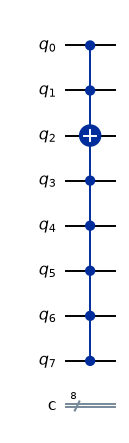

In [14]:
from qiskit import QuantumCircuit, qiskit
from qiskit.visualization import circuit_drawer

qc = qiskit.qasm3.loads(qasm)

display(circuit_drawer(qc, output='mpl', scale=0.7))

In [15]:
from IPython.display import display, HTML
from urllib.parse import unquote

algo = ALGORITHMS[ALGO]
print("Original en Quirk:", unquote(algo["url"]))
display(HTML('<a href="' + encode_quirk_url(algo["url"]) + '" target="_blank">Abrir en Quirk</a>'))


Original en Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H","H","H"],["X"],["X","X","X","X"],[1,"•","X"],[1,"X","•"],[1,"•","X"],[1,1,"•","X"],[1,1,"X","•"],[1,1,"•","X"],["•",1,1,"X"],["X",1,1,"•"],["•",1,1,"X"],["Measure","Measure","Measure","Measure"]],"gates":[{"id":"~rvcr","name":"MultiX","circuit":{"cols":[["•","X","•"]]}},{"id":"~hbrq","name":"yes","circuit":{"cols":[["•","Y"]]}}]}


In [16]:
# @title 7. Probar TODOS los algoritmos
results = {}
for name, algo in ALGORITHMS.items():
    try:
        qasm = quirk_to_qasm(algo['url'], algo['offset'])
        results[name] = {'status': 'OK', 'qasm': qasm}
    except Exception as e:
        results[name] = {'status': f'ERROR: {e}', 'qasm': ''}

md = '| Algoritmo | Status | Líneas QASM |\n|---|---|---|\n'
for name, r in results.items():
    lines = len(r['qasm'].split('\n')) if r['qasm'] else 0
    md += f'| {name} | {r["status"]} | {lines} |\n'
display(Markdown(md))

| Algoritmo | Status | Líneas QASM |
|---|---|---|
| 0. Prueba | OK | 5 |
| 1. Shor | OK | 32 |
| 2. Bernstein-Vazirani | OK | 21 |
| 3. Grover | OK | 16 |
| 4. Deutsch-Jozsa | OK | 25 |
| 5. Simon | OK | 21 |
| 6. TSP | OK | 16 |
| 7. Teleportation | OK | 16 |
| 8. Phase Estimation | OK | 28 |
| 9. QFT | OK | 18 |
| 10. QAOA | OK | 11 |
| 11. Kickback | OK | 15 |
| 12. Full Adder | OK | 19 |


=== 0. Prueba ===


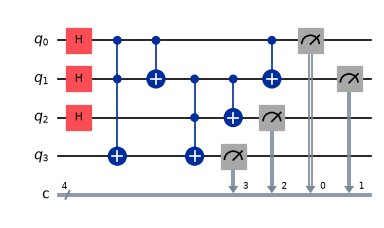


=== 1. Shor ===


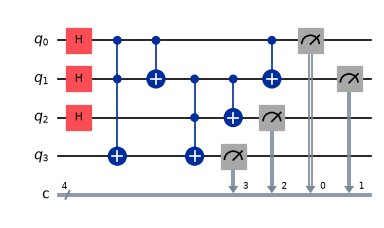


=== 2. Bernstein-Vazirani ===


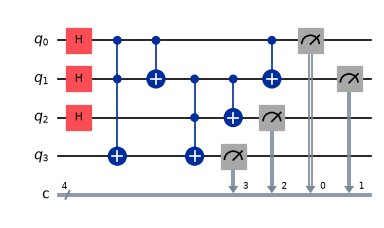


=== 3. Grover ===


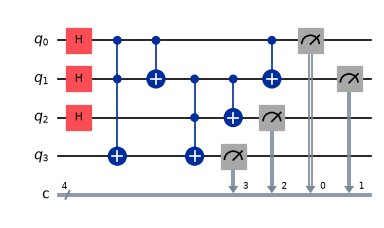


=== 4. Deutsch-Jozsa ===


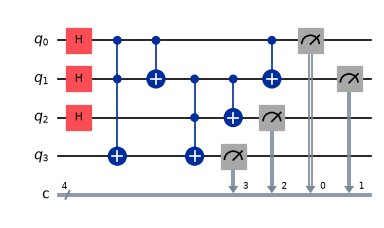


=== 5. Simon ===


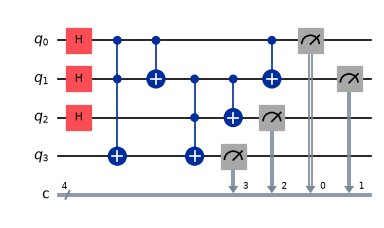


=== 6. TSP ===


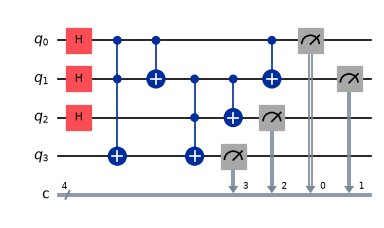


=== 7. Teleportation ===


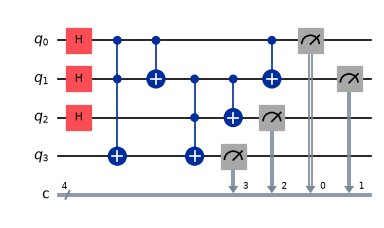


=== 8. Phase Estimation ===


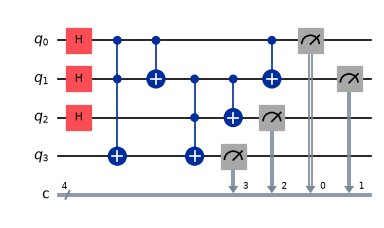


=== 9. QFT ===


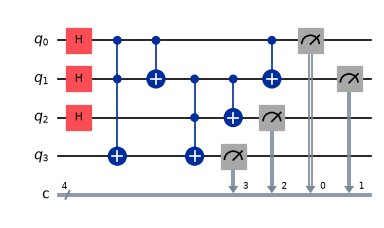


=== 10. QAOA ===


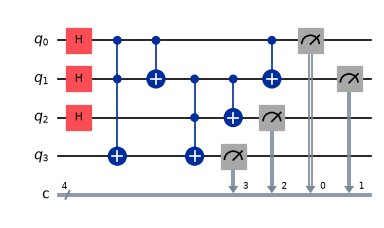


=== 11. Kickback ===


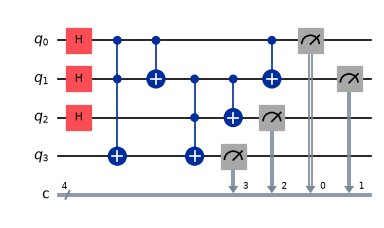


=== 12. Full Adder ===


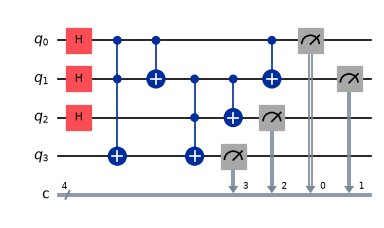

In [20]:
# @title 8. Mostrar TODOS los algoritmos en Qiskit
from html import escape
from urllib.parse import unquote
from IPython.display import display, HTML
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer

for name, algo in ALGORITHMS.items():
    print(f"=== {name} ===")
    readable_url = unquote(algo["url"])
    encoded_url = encode_quirk_url(algo["url"])
    display(HTML(
    f'<a href="{escape(encoded_url, quote=True)}" target="_blank">'
    'Abrir en Quirk'
    '</a>'
    f'<pre style="white-space: pre-wrap; word-break: break-all;">'
    f'{escape(readable_url)}'
    '</pre>')) 
    qc = qiskit.qasm3.loads(qasm)
    display(circuit_drawer(qc, output='mpl', scale=0.6))
    print()


In [21]:
# @title 10. Probar URL personalizada
CUSTOM_URL = "https://algassert.com/quirk#circuit={'cols':[['H'],['•','X'],['Measure','Measure']]}"  # @param {type:"string"}
CUSTOM_OFFSET = 0  # @param {type:"integer"}

try:
    qasm = quirk_to_qasm(CUSTOM_URL, CUSTOM_OFFSET)
    print(qasm)
except Exception as e:
    print(f"Error: {e}")

OPENQASM 3.0;
include "stdgates.inc";
qreg q[2];
creg c[2];
h q[0];
ctrl @ x q[0], q[1];
c[0] = measure q[0];
c[1] = measure q[1];
